In [1]:
from telescope import ACF14, ACF14reduced, K1
from spectrograph import Alpy600
from detector import IMX183

import numpy as np
from astropy import units as u
from synphot import SpectralElement, Observation, SourceSpectrum
from synphot.models import BlackBody1D

from matplotlib import pyplot as plt

In [2]:
Alpy600.generate_binset(IMX183)

In [3]:
t, p = Alpy600.slit_throughput(2.5, ACF14reduced, IMX183)
t

0.2527188022563638

In [4]:
mag = 9
sp = SourceSpectrum.from_vega()*10**(-mag/2.5)

In [5]:
obs = Observation(sp, ACF14reduced.efficiency*Alpy600.efficiency*IMX183.efficiency, binset=Alpy600.binset)

In [6]:
specdata = obs.sample_binned(Alpy600.binset)*Alpy600.AperPix*ACF14reduced.area
np.sum(specdata), obs.countrate(ACF14reduced.area)

(<Quantity 88078.65020585 cm2 A PHOTLAM>, <Quantity 88078.65020585 ct / s>)

In [7]:
exptime = 10*u.second
RN = 1.2
SNR = (specdata*exptime).value / ( (specdata*exptime).value + np.ones(specdata.shape)*RN**2)**0.5

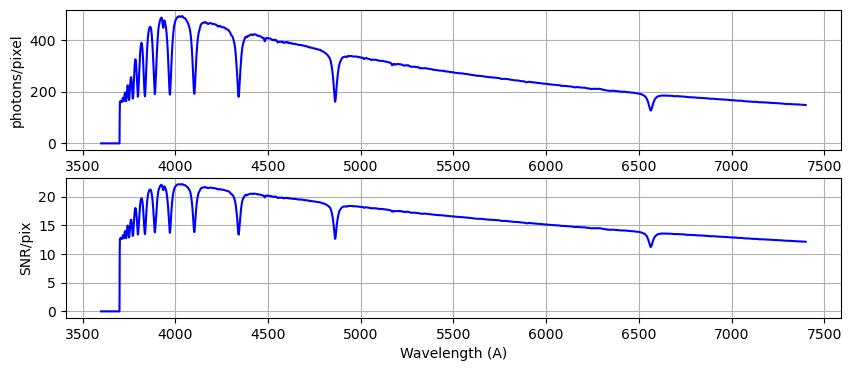

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(2,1,1)
plt.plot(Alpy600.binset, specdata*exptime, 'b-')
plt.xlabel('Wavelength (A)')
plt.ylabel('photons/pixel')
plt.grid()

plt.subplot(2,1,2)
plt.plot(Alpy600.binset, SNR, 'b-')
plt.xlabel('Wavelength (A)')
plt.ylabel('SNR/pix')
plt.grid()

plt.show()